Loading MNIST dataset...

--- Starting Training Loop ---
Epoch 01/10 | Cross-Entropy Loss: 0.0451
Epoch 02/10 | Cross-Entropy Loss: 0.0262
Epoch 03/10 | Cross-Entropy Loss: 0.0219
Epoch 04/10 | Cross-Entropy Loss: 0.0189
Epoch 05/10 | Cross-Entropy Loss: 0.0176
Epoch 06/10 | Cross-Entropy Loss: 0.0158
Epoch 07/10 | Cross-Entropy Loss: 0.0145
Epoch 08/10 | Cross-Entropy Loss: 0.0136
Epoch 09/10 | Cross-Entropy Loss: 0.0128
Epoch 10/10 | Cross-Entropy Loss: 0.0121


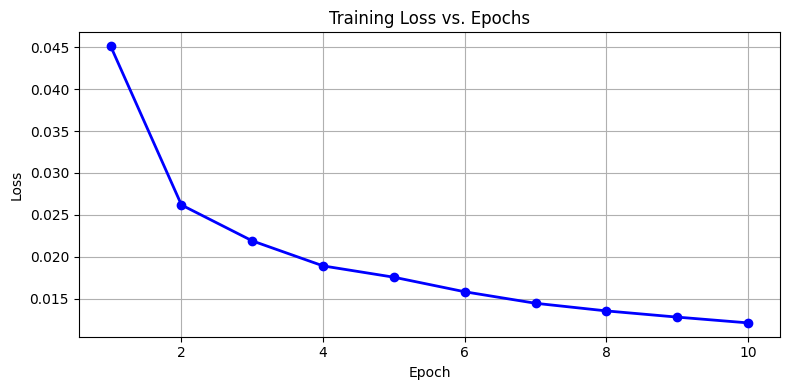

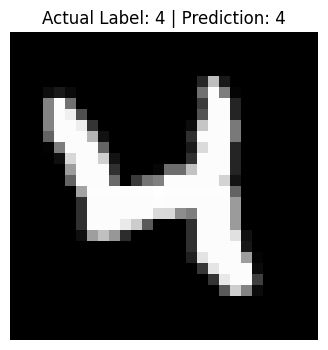

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train_flat = X_train.reshape(-1, 784) / 255.0
X_test_flat = X_test.reshape(-1, 784) / 255.0

encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))

input_size = 784
hidden_size = 64
output_size = 10

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(a):
    return a * (1 - a)

def loss_fn(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

epochs = 10
lr = 0.1
losses = []

print("\n--- Starting Training Loop ---")
for epoch in range(epochs):
    total_loss = 0
    num_samples = X_train_flat.shape[0]

    for i in range(num_samples):
        x = X_train_flat[i:i+1]
        y = y_train_encoded[i:i+1]

        z1 = x @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        loss = loss_fn(y, a2)
        total_loss += loss

        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    avg_loss = total_loss / num_samples
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Cross-Entropy Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), losses, marker='o', color='b', linewidth=2)
plt.title("Training Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

def predict(img_vector):
    a1 = sigmoid(img_vector @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return np.argmax(a2)

idx = 20
sample_img_flat = X_train_flat[idx:idx+1]
predicted_label = predict(sample_img_flat)

plt.figure(figsize=(4, 4))
plt.imshow(X_train[idx], cmap='gray')
plt.title(f"Actual Label: {y_train[idx]} | Prediction: {predicted_label}")
plt.axis('off')
plt.show()